In [1]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Cell 2: Load cleaned data
df = pd.read_csv('../../data/processed/cleaned_data.csv')

print(f"Dataset loaded: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

Dataset loaded: (40801, 18)

Columns: ['id_student', 'final_result', 'avg_days_to_deadline', 'std_days_to_deadline', 'earliest_submission', 'latest_submission', 'avg_score', 'num_submissions', 'num_login_days', 'total_clicks', 'last_minute_ratio', 'engagement_intensity', 'deadline_pressure', 'login_consistency', 'early_starter', 'completion_rate', 'activity_span', 'high_risk']

First few rows:
   id_student final_result  avg_days_to_deadline  std_days_to_deadline  \
0       11391         Pass                  -1.8              0.836660   
1       28400         Pass                   0.0              3.240370   
2       30268    Withdrawn                   0.0              0.000000   
3       31604         Pass                  -2.0              0.707107   
4       32885         Pass                  11.4              6.387488   

   earliest_submission  latest_submission  avg_score  num_submissions  \
0                 -3.0               -1.0       82.0              5.0   
1           

In [3]:
# Cell 3: Define features and target
# These are the 7 features we engineered on Day 2
feature_columns = [
    'last_minute_ratio',
    'engagement_intensity', 
    'deadline_pressure',
    'login_consistency',
    'early_starter',
    'completion_rate',
    'activity_span'
]

target_column = 'high_risk'

# Extract features and target
X = df[feature_columns].copy()
y = df[target_column].copy()

print("Feature Matrix (X):")
print(f"  Shape: {X.shape}")
print(f"  Features: {feature_columns}")
print(f"\nTarget Variable (y):")
print(f"  Shape: {y.shape}")
print(f"  Distribution:\n{y.value_counts()}")
print(f"  High-risk percentage: {y.mean()*100:.1f}%")

Feature Matrix (X):
  Shape: (40801, 7)
  Features: ['last_minute_ratio', 'engagement_intensity', 'deadline_pressure', 'login_consistency', 'early_starter', 'completion_rate', 'activity_span']

Target Variable (y):
  Shape: (40801,)
  Distribution:
high_risk
1    23688
0    17113
Name: count, dtype: int64
  High-risk percentage: 58.1%


In [4]:
# Cell 4: Check for missing values and data quality
print("Data Quality Check:")
print("=" * 60)
print(f"\nMissing values in features:")
print(X.isnull().sum())
print(f"\nMissing values in target:")
print(y.isnull().sum())

# Handle any missing values (if any)
if X.isnull().sum().sum() > 0:
    print(f"\n⚠️  Found {X.isnull().sum().sum()} missing values - filling with 0")
    X = X.fillna(0)

# Check for infinite values
inf_count = np.isinf(X).sum().sum()
if inf_count > 0:
    print(f"\n⚠️  Found {inf_count} infinite values - replacing with 0")
    X = X.replace([np.inf, -np.inf], 0)

print("\n✅ Data is clean and ready for training!")

Data Quality Check:

Missing values in features:
last_minute_ratio       6773
engagement_intensity       0
deadline_pressure          0
login_consistency          0
early_starter              0
completion_rate            0
activity_span              0
dtype: int64

Missing values in target:
0

⚠️  Found 6773 missing values - filling with 0

✅ Data is clean and ready for training!


In [5]:
# Cell 5: Feature statistics by class
print("Feature Statistics by Risk Level:")
print("=" * 60)

for feature in feature_columns:
    print(f"\n{feature}:")
    print(f"  High Risk - Mean: {X[y==1][feature].mean():.3f}, Std: {X[y==1][feature].std():.3f}")
    print(f"  Low Risk  - Mean: {X[y==0][feature].mean():.3f}, Std: {X[y==0][feature].std():.3f}")
    print(f"  Difference: {X[y==1][feature].mean() - X[y==0][feature].mean():.3f}")

Feature Statistics by Risk Level:

last_minute_ratio:
  High Risk - Mean: 0.280, Std: 0.324
  Low Risk  - Mean: 0.361, Std: 0.252
  Difference: -0.080

engagement_intensity:
  High Risk - Mean: 16.703, Std: 12.955
  Low Risk  - Mean: 22.545, Std: 11.800
  Difference: -5.842

deadline_pressure:
  High Risk - Mean: 1.383, Std: 3.851
  Low Risk  - Mean: 0.376, Std: 0.715
  Difference: 1.007

login_consistency:
  High Risk - Mean: 12.833, Std: 28.053
  Low Risk  - Mean: 21.677, Std: 28.094
  Difference: -8.844

early_starter:
  High Risk - Mean: 0.233, Std: 0.423
  Low Risk  - Mean: 0.568, Std: 0.495
  Difference: -0.334

completion_rate:
  High Risk - Mean: 0.535, Std: 0.426
  Low Risk  - Mean: 0.986, Std: 0.056
  Difference: -0.451

activity_span:
  High Risk - Mean: 31.839, Std: 69.541
  Low Risk  - Mean: 62.591, Std: 80.580
  Difference: -30.751


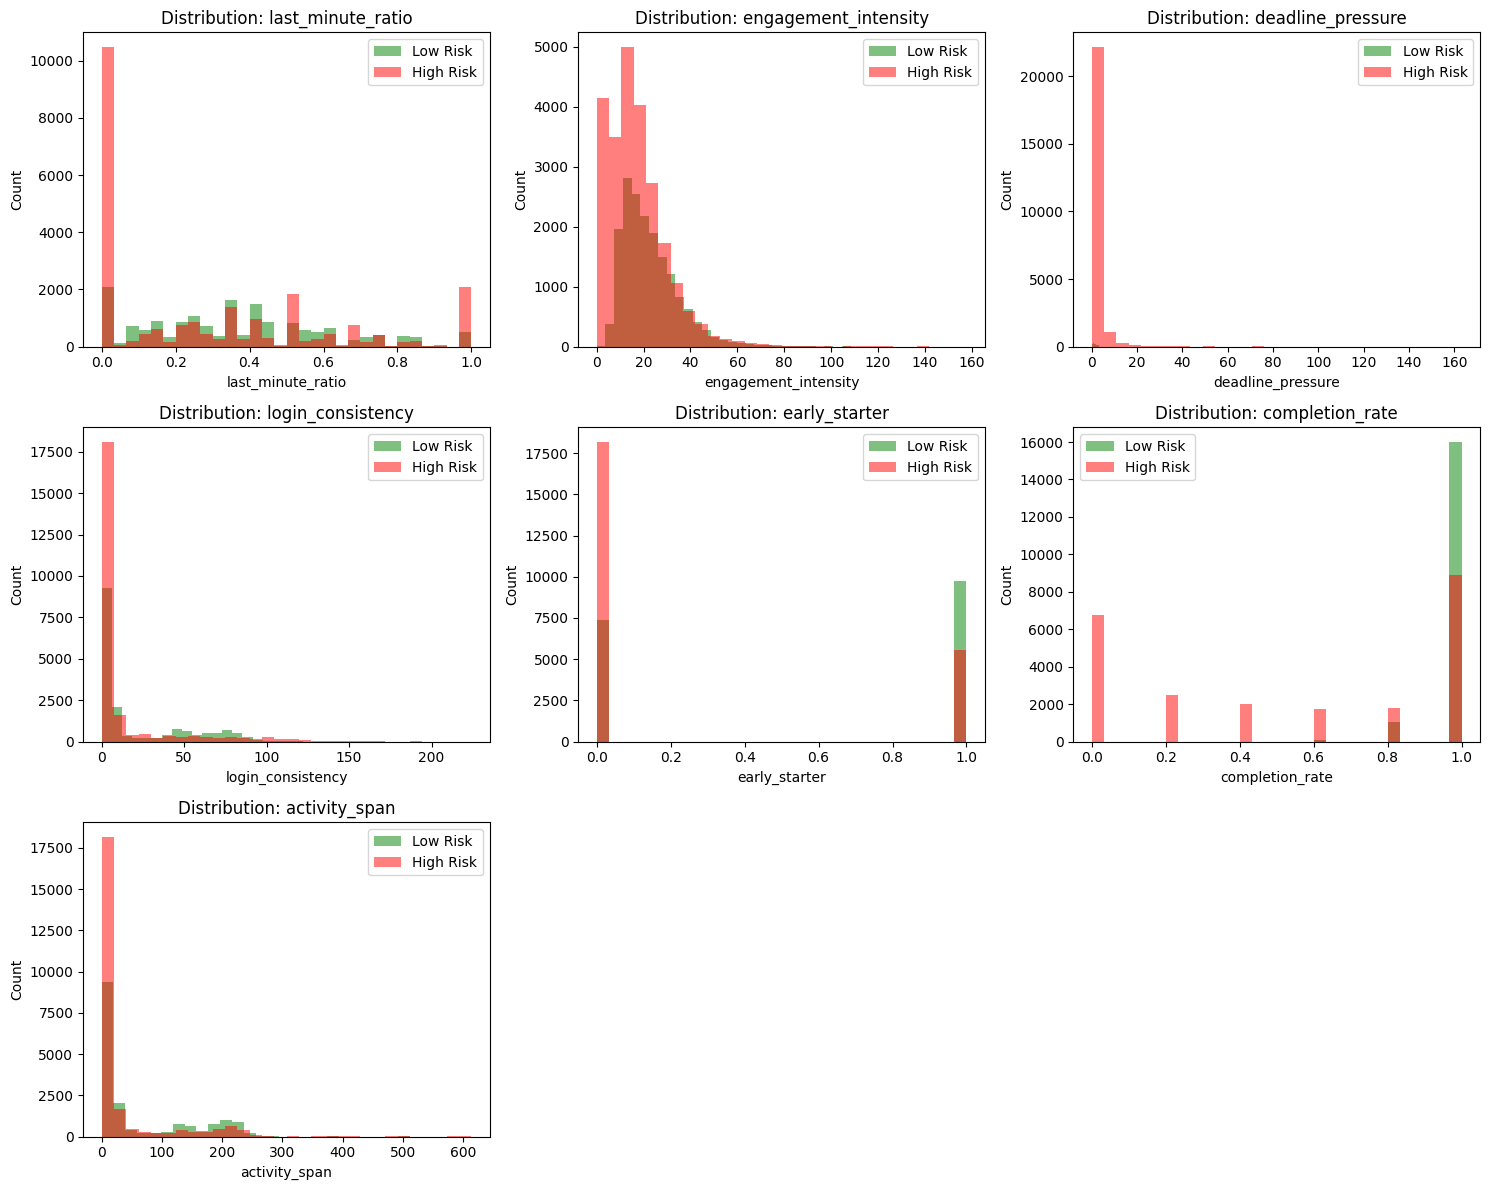

In [6]:
# Cell 6: Visualize feature distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(feature_columns):
    axes[idx].hist(X[y==0][feature], bins=30, alpha=0.5, label='Low Risk', color='green')
    axes[idx].hist(X[y==1][feature], bins=30, alpha=0.5, label='High Risk', color='red')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Count')
    axes[idx].legend()
    axes[idx].set_title(f'Distribution: {feature}')

# Hide unused subplots
for idx in range(len(feature_columns), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Cell 7: Split data into training and testing sets
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class balance
)

print("Train/Test Split:")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nClass distribution in training:")
print(y_train.value_counts())
print(f"High-risk: {y_train.mean()*100:.1f}%")
print(f"\nClass distribution in testing:")
print(y_test.value_counts())
print(f"High-risk: {y_test.mean()*100:.1f}%")

Train/Test Split:
Training set: 32640 samples (80.0%)
Testing set:  8161 samples (20.0%)

Class distribution in training:
high_risk
1    18950
0    13690
Name: count, dtype: int64
High-risk: 58.1%

Class distribution in testing:
high_risk
1    4738
0    3423
Name: count, dtype: int64
High-risk: 58.1%


In [8]:
# Cell 8: Feature scaling (important for some models)
# Random Forest doesn't strictly need scaling, but we'll do it for completeness
scaler = StandardScaler()

# Fit on training data only (avoid data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns)

print("✅ Features scaled using StandardScaler")
print(f"\nScaled training data shape: {X_train_scaled.shape}")
print(f"\nSample scaled values:")
print(X_train_scaled.head())

# Save the scaler for later use
joblib.dump(scaler, '../src/scaler.pkl')
print("\n✅ Scaler saved to: src/scaler.pkl")

✅ Features scaled using StandardScaler

Scaled training data shape: (32640, 7)

Sample scaled values:
   last_minute_ratio  engagement_intensity  deadline_pressure  \
0           1.814454              0.059019          -0.335243   
1           1.623315              0.031978           0.229889   
2           0.858757             -0.432043           0.522547   
3           0.062343              2.563095          -0.174694   
4          -1.052637             -1.027014          -0.335243   

   login_consistency  early_starter  completion_rate  activity_span  
0          -0.342730       1.297261         0.695958      -0.352114  
1          -0.456324      -0.770855         0.695958      -0.484295  
2          -0.395023      -0.770855         0.695958      -0.391768  
3          -0.496975      -0.770855         0.695958      -0.497513  
4          -0.582316      -0.770855        -1.836378      -0.590040  

✅ Scaler saved to: src/scaler.pkl


In [9]:
# Cell 9: Train Logistic Regression (simple baseline)
print("Training Logistic Regression (Baseline)...")
print("=" * 60)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_pred_proba_lr)

print("\n📊 Logistic Regression Results:")
print(f"  Accuracy:  {lr_accuracy:.3f}")
print(f"  Precision: {lr_precision:.3f}")
print(f"  Recall:    {lr_recall:.3f}")
print(f"  F1-Score:  {lr_f1:.3f}")
print(f"  ROC-AUC:   {lr_auc:.3f}")

print("\n✅ Baseline model trained!")

Training Logistic Regression (Baseline)...

📊 Logistic Regression Results:
  Accuracy:  0.809
  Precision: 0.893
  Recall:    0.763
  F1-Score:  0.823
  ROC-AUC:   0.873

✅ Baseline model trained!


In [10]:
# Cell 10: Train Random Forest Classifier
print("Training Random Forest Classifier...")
print("=" * 60)

# Initialize Random Forest with good default parameters
rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    max_depth=10,            # Max depth of each tree
    min_samples_split=20,    # Min samples to split a node
    min_samples_leaf=10,     # Min samples in leaf node
    random_state=42,
    n_jobs=-1,               # Use all CPU cores
    verbose=1                # Show progress
)

# Train the model
rf_model.fit(X_train, y_train)  # Random Forest works well with unscaled data

print("\n✅ Random Forest trained!")

import joblib
import os

# Create the folder if it's missing
os.makedirs('../src/models/', exist_ok=True)

# Save using the specific name predict.py is looking for
joblib.dump(rf_model, '../src/models/rf_procrastination_model.pkl')
# Save the scaler too, as version mismatches here cause huge score errors
joblib.dump(scaler, '../src/models/scaler.pkl') 
joblib.dump(X.columns.tolist(), '../src/models/feature_names.pkl')

print("✅ COMPATIBLE MODEL SAVED!")

Training Random Forest Classifier...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.1s finished



✅ Random Forest trained!
✅ COMPATIBLE MODEL SAVED!


In [11]:
# Cell 11: Make predictions with Random Forest
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_pred_proba_rf)

print("📊 Random Forest Results:")
print("=" * 60)
print(f"  Accuracy:  {rf_accuracy:.3f} ({rf_accuracy*100:.1f}%)")
print(f"  Precision: {rf_precision:.3f}")
print(f"  Recall:    {rf_recall:.3f}")
print(f"  F1-Score:  {rf_f1:.3f}")
print(f"  ROC-AUC:   {rf_auc:.3f}")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


📊 Random Forest Results:
  Accuracy:  0.838 (83.8%)
  Precision: 0.972
  Recall:    0.743
  F1-Score:  0.842
  ROC-AUC:   0.910


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [12]:
# Cell 12: Compare models side-by-side
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy],
    'Precision': [lr_precision, rf_precision],
    'Recall': [lr_recall, rf_recall],
    'F1-Score': [lr_f1, rf_f1],
    'ROC-AUC': [lr_auc, rf_auc]
})

print("\n📊 MODEL COMPARISON:")
print("=" * 60)
print(comparison_df.to_string(index=False))

# Determine best model
best_model_name = 'Random Forest' if rf_f1 > lr_f1 else 'Logistic Regression'
best_model = rf_model if rf_f1 > lr_f1 else lr_model
print(f"\n🏆 Best Model: {best_model_name}")


📊 MODEL COMPARISON:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.809460   0.893449 0.762769  0.822953 0.873326
      Random Forest  0.838255   0.971578 0.743141  0.842143 0.909955

🏆 Best Model: Random Forest


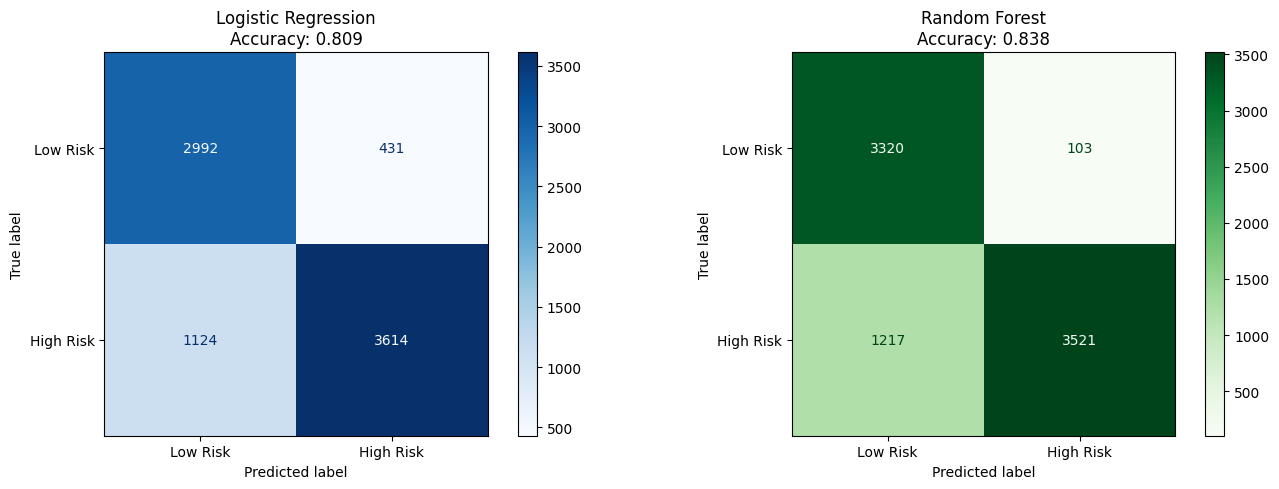


📊 Random Forest Confusion Matrix Interpretation:
True Negatives (correctly predicted low-risk):  3320
False Positives (low-risk predicted as high):   103
False Negatives (high-risk predicted as low):   1217
True Positives (correctly predicted high-risk): 3521


In [13]:
# Cell 13: Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, 
                                  display_labels=['Low Risk', 'High Risk'])
disp_lr.plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Logistic Regression\nAccuracy: {lr_accuracy:.3f}')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                  display_labels=['Low Risk', 'High Risk'])
disp_rf.plot(ax=axes[1], cmap='Greens')
axes[1].set_title(f'Random Forest\nAccuracy: {rf_accuracy:.3f}')

plt.tight_layout()
plt.show()

# Interpret confusion matrix for Random Forest
print("\n📊 Random Forest Confusion Matrix Interpretation:")
print("=" * 60)
print(f"True Negatives (correctly predicted low-risk):  {cm_rf[0,0]}")
print(f"False Positives (low-risk predicted as high):   {cm_rf[0,1]}")
print(f"False Negatives (high-risk predicted as low):   {cm_rf[1,0]}")
print(f"True Positives (correctly predicted high-risk): {cm_rf[1,1]}")

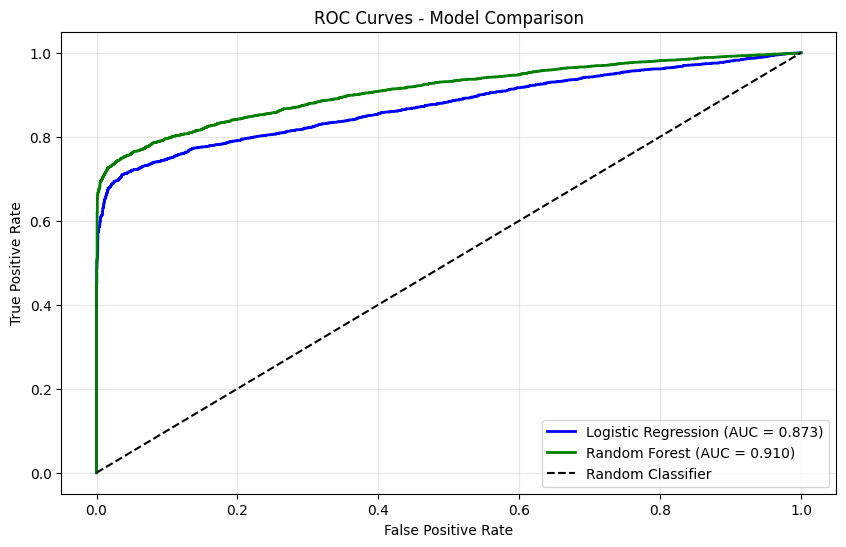

In [14]:
# Cell 14: ROC Curve
plt.figure(figsize=(10, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_auc:.3f})', 
         linewidth=2, color='blue')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.3f})', 
         linewidth=2, color='green')

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


🔍 FEATURE IMPORTANCE:
             feature  importance
     completion_rate    0.383924
   deadline_pressure    0.174038
   login_consistency    0.168354
       activity_span    0.149779
   last_minute_ratio    0.056126
       early_starter    0.036478
engagement_intensity    0.031302


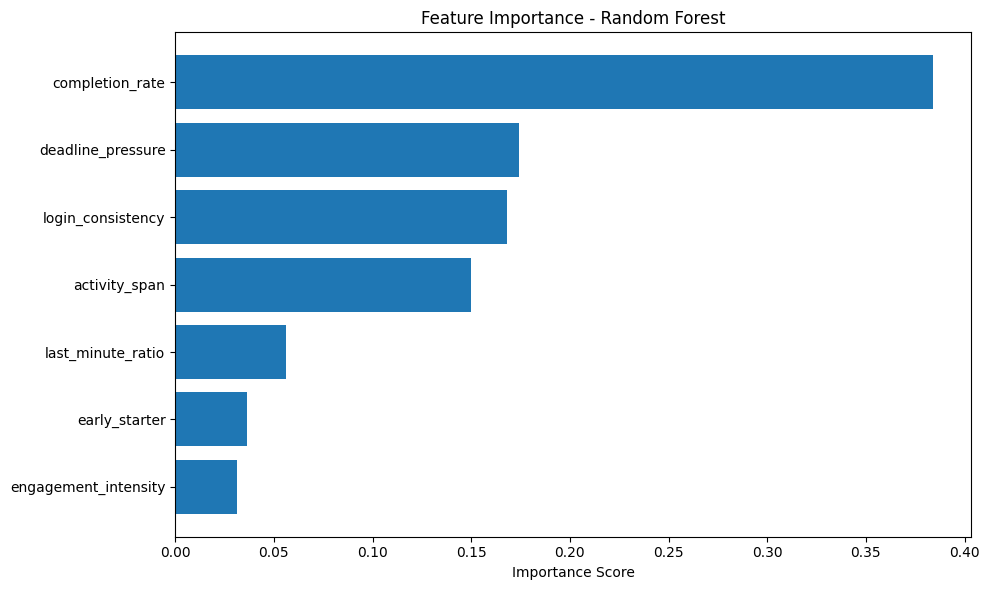

In [15]:
# Cell 15: Feature Importance (Random Forest only)
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🔍 FEATURE IMPORTANCE:")
print("=" * 60)
print(feature_importance.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
# Cell 16: Detailed classification report
print("\n📋 DETAILED CLASSIFICATION REPORT:")
print("=" * 60)
print("\nRandom Forest:")
print(classification_report(y_test, y_pred_rf, 
                           target_names=['Low Risk', 'High Risk']))


📋 DETAILED CLASSIFICATION REPORT:

Random Forest:
              precision    recall  f1-score   support

    Low Risk       0.73      0.97      0.83      3423
   High Risk       0.97      0.74      0.84      4738

    accuracy                           0.84      8161
   macro avg       0.85      0.86      0.84      8161
weighted avg       0.87      0.84      0.84      8161



In [17]:
# Cell 17: Save the best model
import os

# Create models directory
os.makedirs('../src/models', exist_ok=True)

# Save Random Forest model
model_path = '../src/models/rf_procrastination_model.pkl'
joblib.dump(rf_model, model_path)
print(f"✅ Model saved to: {model_path}")

# Save feature names (important for production)
feature_names_path = '../src/models/feature_names.pkl'
joblib.dump(feature_columns, feature_names_path)
print(f"✅ Feature names saved to: {feature_names_path}")

# Save model metadata
metadata = {
    'model_type': 'RandomForestClassifier',
    'accuracy': rf_accuracy,
    'precision': rf_precision,
    'recall': rf_recall,
    'f1_score': rf_f1,
    'roc_auc': rf_auc,
    'n_estimators': 100,
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'feature_names': feature_columns,
    'trained_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

import json
metadata_path = '../src/models/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"✅ Metadata saved to: {metadata_path}")

✅ Model saved to: ../src/models/rf_procrastination_model.pkl
✅ Feature names saved to: ../src/models/feature_names.pkl
✅ Metadata saved to: ../src/models/model_metadata.json


In [18]:
# Cell 18: Test loading the saved model
print("\n🧪 Testing model loading...")
loaded_model = joblib.load(model_path)
loaded_features = joblib.load(feature_names_path)

# Make a test prediction
test_sample = X_test.iloc[0:1]
prediction = loaded_model.predict(test_sample)
probability = loaded_model.predict_proba(test_sample)[0]

print(f"\n✅ Model loaded successfully!")
print(f"\nTest prediction:")
print(f"  Features: {test_sample.values[0]}")
print(f"  Prediction: {'High Risk' if prediction[0] == 1 else 'Low Risk'}")
print(f"  Probability: {probability[1]*100:.1f}% high-risk")


🧪 Testing model loading...

✅ Model loaded successfully!

Test prediction:
  Features: [0. 0. 0. 0. 0. 0. 0.]
  Prediction: High Risk
  Probability: 100.0% high-risk


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [19]:
import joblib
import os

target_path = '../src/models/rf_procrastination_model.pkl' 

joblib.dump(loaded_model, target_path)
print(f"✅ Successfully overwritten: {target_path}")

# # Ensure the directory exists
# os.makedirs('../src/models/', exist_ok=True)

# # Save the model and any other required components
# # Replace 'rf_model' and 'X_train' with the actual variable names from your notebook
# joblib.dump(rf_model, '../src/models/rf_procrastination_model.pkl')
# # If your predict.py also needs the feature names or scaler:
# # joblib.dump(X.columns.tolist(), '../src/models/feature_names.joblib')

# print("✅ Model files saved to backend/src/models/ with today's timestamp!")

✅ Successfully overwritten: ../src/models/rf_procrastination_model.pkl
